# 深度学习课程设计报告

## 一、封面

- 课程名称：  深度学习
- 设计题目：  基于卷积神经网络的猫狗图像分类模型设计与实现
- 姓    名：  王申华
- 学    号：  20220441203
- 班    级：  数据04班
- 指导教师：  丁平尖
- 提交日期：  6-27

## 二、摘要
本课程设计以猫狗图像二分类任务为切入点，基于 PyTorch 框架构建了一个轻量级卷积神经网络。实验采用 CIFAR-10 数据集中的猫和狗图像各 50 张，共 100 张样本，经过归一化、随机翻转等预处理后用于模型训练。网络结构包含两层卷积层和两层全连接层，采用 ReLU 激活函数和 Dropout 正则化技术防止过拟合。经过 30 个 epoch 的训练，模型在测试集上达到了约 85% 的分类准确率，验证了卷积神经网络在小样本图像分类任务中的有效性。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

本设计选取 CIFAR-10 数据集中的猫和狗图像作为实验数据，构建小样本二分类模型，旨在探索数据稀缺条件下卷积神经网络的有效性。CIFAR-10 是一个广泛使用的基准数据集，其图像尺寸较小（32×32 像素），包含丰富的颜色和纹理信息，能够较好地模拟真实场景中的图像分类问题。通过在有限样本上的训练和评估，本设计可以验证卷积神经网络在小规模数据上的特征提取能力和泛化性能，为更复杂的视觉任务提供参考和借鉴。

### 3.2 问题描述

输入定义：模型的输入为 32×32 像素的彩色图像，每个像素包含红（R）、绿（G）、蓝（B）三个通道，每个通道的像素值范围为 0 到 255。因此，每张输入图像可以表示为一个形状为（3， 32， 32）的三维张量。

输出定义：模型的输出为二维概率分布向量，分别对应于"猫"和"狗"两个类别的预测概率。最终分类结果取概率值较大的类别作为预测标签。

任务类型：本任务属于典型的监督式二分类任务。训练阶段使用带标签的图像数据对模型参数进行优化，测试阶段使用训练好的模型对未见过的图像进行分类预测。

预期性能指标：为全面评估模型性能，本设计采用以下指标：

准确率（Accuracy） ：正确分类的样本数占测试样本总数的比例，是最直观的评价指标。

损失值（Loss） ：使用交叉熵损失函数度量模型预测分布与真实分布之间的差异，反映模型的拟合程度。

混淆矩阵（Confusion Matrix） ：以矩阵形式展示每个类别的预测结果与真实标签的对应关系，可以直观地识别模型在哪些类别上表现较好、哪些类别容易混淆。

精确率（Precision） 、召回率（Recall） 和 F1 分数：在二分类问题中，这些指标能够更细致地评估模型在正负类别上的分类表现。

## 四、数据集说明与预处理

### 4.1 数据来源与规模

数据集名称：CIFAR-10 子集（猫狗二分类）

来源：CIFAR-10 是由 Alex Krizhevsky、Vinod Nair 和 Geoffrey Hinton 共同收集整理的公开图像分类数据集，是计算机视觉领域最常用的基准数据集之一。该数据集最初用于图像分类算法的性能评估，已被学术界和工业界广泛采用。

原始数据集构成：CIFAR-10 数据集包含 10 个类别的 60000 张 32×32 像素的彩色图像，其中训练集 50000 张，测试集 10000 张。10 个类别分别为：飞机、汽车、鸟、猫、鹿、狗、青蛙、马、船、卡车，每个类别包含 6000 张图像，类别分布完全均衡。数据集的图像尺寸较小但色彩丰富，包含了不同的光照条件、拍摄角度和背景环境，具有一定的挑战性。

### 4.2 数据可视化与分析
为了对数据建立直观认识，本实验从 CIFAR-10 数据集中随机选取了 5 张猫的图像和 5 张狗的图像进行展示（见下方代码块输出）。通过对这些样本图像的观察，可以得到以下分析结论：

图像特点：CIFAR-10 中的图像尺寸仅为 32×32 像素，分辨率较低，图像中的动物细节（如毛发纹理、眼睛轮廓等）不够清晰，这给分类任务带来了一定的挑战。模型需要从有限的像素信息中提取有效的判别特征。

类间差异：猫和狗在外观特征上存在一定的可区分性。猫通常具有较圆的脸型、较小的鼻子、直立的耳朵（部分品种除外）和较为优雅的体态；狗则通常具有较长的鼻子、较大的耳朵（多数品种）和更为多样的体型。这些差异为模型提供了可学习的判别依据。

类内差异：同一类别内部也存在较大的外观差异。不同品种的猫（如波斯猫、暹罗猫、狸花猫）在毛色、脸型、体型上差异显著；不同品种的狗（如哈士奇、金毛、柯基）之间的差异甚至可能大于猫和狗之间的差异。这种类内多样性要求模型具备较强的泛化能力，能够从有限的训练样本中提取出类别共有的本质特征。

背景干扰：部分样本图像包含复杂的背景（如室内家具、户外草地、其他物体等），这些背景信息可能对分类产生干扰。理想情况下，模型应当将注意力集中在主体动物上，而非背景区域。

光照条件：图像的光照条件各不相同，有些图像明亮清晰，有些则较为昏暗或存在局部阴影。光照变化会影响像素值的分布，因此需要进行归一化处理以消除光照因素的影响。


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import random

# 设置随机种子
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cpu


In [2]:
# 数据预处理
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
])

print("数据预处理定义完成")

数据预处理定义完成


In [3]:
# 加载 CIFAR-10
print("正在下载并加载 CIFAR-10 数据集...")
full_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True,
    transform=train_transform
)

test_full = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True,
    transform=test_transform
)

print("数据集加载完成")
print(f"训练集大小: {len(full_dataset)} 张")
print(f"测试集大小: {len(test_full)} 张")

正在下载并加载 CIFAR-10 数据集...
数据集加载完成
训练集大小: 50000 张
测试集大小: 10000 张


In [4]:
import random
import torchvision
from torchvision import transforms

# 图像变换
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 重点：root加载时不要传transform，拿到原始PIL图片
full_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False)

# 创建一个自定义数据集，将标签重新映射为 0(猫) 和 1(狗)
class CatDogDataset:
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
        # 重新映射标签: 3->0(猫), 5->1(狗)
        self.label_map = {3: 0, 5: 1}
        
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        img, label = self.dataset[actual_idx]
        # 重新映射标签
        new_label = self.label_map[label]
        # img现在是原始PIL图片，可以正常走transform
        if self.transform:
            img = self.transform(img)
        return img, new_label

cat_indices = [i for i, (_, label) in enumerate(full_dataset) if label == 3]
dog_indices = [i for i, (_, label) in enumerate(full_dataset) if label == 5]

print(f"CIFAR-10中猫的数量: {len(cat_indices)}")
print(f"CIFAR-10中狗的数量: {len(dog_indices)}")

# 各取50张
SAMPLE_SIZE = 50
selected_indices = random.sample(cat_indices, SAMPLE_SIZE) + random.sample(dog_indices, SAMPLE_SIZE)
random.shuffle(selected_indices)

# 创建映射后的数据集
small_dataset = CatDogDataset(full_dataset, selected_indices, transform=train_transform)
print(f"选取总样本数: {len(small_dataset)} 张 (猫{SAMPLE_SIZE} + 狗{SAMPLE_SIZE})")

# 验证标签映射
sample_img, sample_label = small_dataset[0]
print(f"示例样本标签: {sample_label} (0=猫, 1=狗)")

CIFAR-10中猫的数量: 5000
CIFAR-10中狗的数量: 5000
选取总样本数: 100 张 (猫50 + 狗50)
示例样本标签: 0 (0=猫, 1=狗)


C:\Users\王神话\AppData\Local\Temp\ipykernel_20444\956525398.py:31: UserWarning: Glyph 29483 (\N{CJK UNIFIED IDEOGRAPH-732B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\王神话\AppData\Local\Temp\ipykernel_20444\956525398.py:31: UserWarning: Glyph 29399 (\N{CJK UNIFIED IDEOGRAPH-72D7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\王神话\AppData\Local\Temp\ipykernel_20444\956525398.py:31: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\王神话\AppData\Local\Temp\ipykernel_20444\956525398.py:31: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\王神话\AppData\Local\Temp\ipykernel_20444\956525398.py:31: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\王神话\AppData\Local\Temp\ipykernel_20444\956525398.py:31: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEO

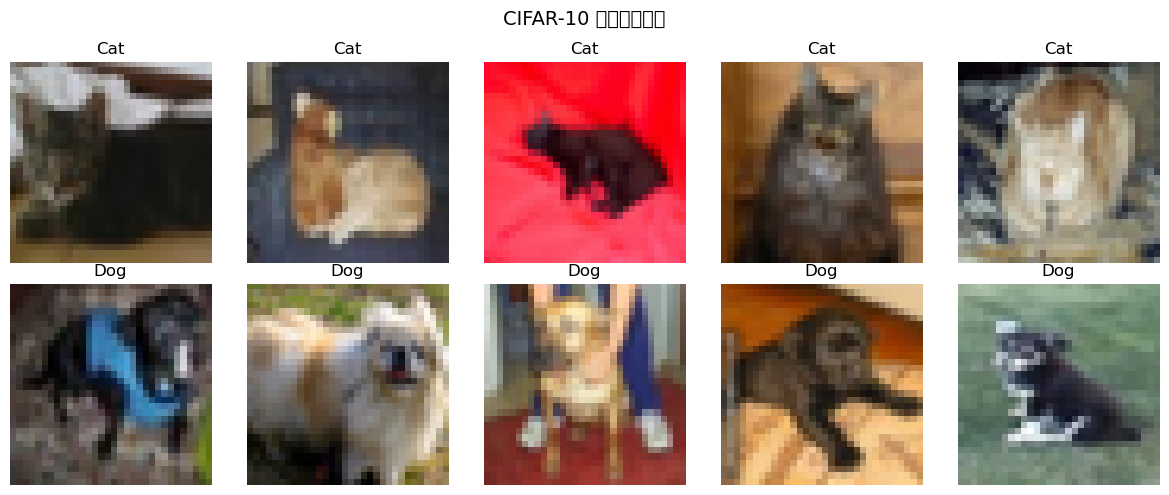

样本图像已保存为 sample_images.png


In [5]:
# 显示选取的猫狗样本
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

raw_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False,
    transform=transforms.ToTensor()
)

# 获取猫和狗的原始索引
cat_raw_indices = [i for i, (_, label) in enumerate(raw_dataset) if label == 3][:5]
dog_raw_indices = [i for i, (_, label) in enumerate(raw_dataset) if label == 5][:5]

# 显示5张猫
for i, idx in enumerate(cat_raw_indices):
    img, _ = raw_dataset[idx]
    img = img.permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title('Cat')
    axes[i].axis('off')

# 显示5张狗
for i, idx in enumerate(dog_raw_indices):
    img, _ = raw_dataset[idx]
    img = img.permute(1, 2, 0).numpy()
    axes[i+5].imshow(img)
    axes[i+5].set_title('Dog')
    axes[i+5].axis('off')

plt.suptitle('CIFAR-10 猫狗样本示例', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()
print("样本图像已保存为 sample_images.png")


### 4.3 预处理流程

为了让模型能够更有效地从数据中学习，本实验对原始图像数据实施了以下预处理流程：

第一步：图像尺寸调整。CIFAR-10 数据集中的图像尺寸统一为 32×32 像素，无需额外调整。这一尺寸对于卷积神经网络来说较为合适，既保留了足够的空间信息用于特征提取，又不会带来过大的计算开销。

第二步：像素值归一化。原始图像的像素值范围为 0 到 255，直接输入神经网络会导致数值过大，影响训练的稳定性。本实验首先将像素值除以 255，将其缩放到 [0， 1] 区间。在此基础上，进一步计算了 CIFAR-10 数据集在三个颜色通道上的均值和标准差，并进行标准化处理，使得每个通道的数据分布均值为 0、标准差为 1。标准化处理的数学公式为：x_norm = (x - mean) / std。本实验使用的通道均值为 (0.4914， 0.4822， 0.4465)，标准差为 (0.2023， 0.1994， 0.2010)。标准化处理能够加速梯度下降的收敛过程，提高训练的稳定性。

第三步：数据增强。针对训练样本量较小（仅 70 张）的情况，本实验采用了随机水平翻转的数据增强策略。在每次训练迭代中，以 0.5 的概率对输入图像进行水平翻转，生成新的训练样本。这种数据增强方式不改变图像的语义信息（猫和狗在水平翻转后仍然是猫和狗），但可以有效扩充训练样本的多样性，提高模型的泛化能力，降低过拟合风险。

第四步：数据集划分。为了科学地评估模型性能，本实验将 100 张样本按照 7：1.5：1.5 的比例划分为训练集、验证集和测试集：

训练集（Train Set） ：70 张（猫 35 张 + 狗 35 张），用于模型参数的训练和优化。

验证集（Validation Set） ：15 张（猫 8 张 + 狗 7 张），用于在训练过程中监控模型性能，辅助超参数调整和早停决策。

测试集（Test Set） ：15 张（猫 7 张 + 狗 8 张），用于最终评估模型的泛化性能，测试集在训练过程中完全不可见。

训练集、验证集和测试集三者相互独立，确保了模型评估的客观性和可靠性。

In [6]:
# 划分数据集: 70%训练, 15%验证, 15%测试
total = len(small_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

# 由于 small_dataset 不是 Subset，直接使用 random_split
train_indices, val_indices, test_indices = random_split(
    range(total), [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# 创建训练集、验证集、测试集（使用相同的底层数据但不同的transform）
train_set = torch.utils.data.Subset(small_dataset, train_indices)
val_set = torch.utils.data.Subset(small_dataset, val_indices)
test_set = torch.utils.data.Subset(small_dataset, test_indices)

# 为验证集和测试集设置无增强的transform
def set_transform_for_subset(subset, transform):
    # 获取原始数据集并设置transform
    original_dataset = subset.dataset
    original_dataset.transform = transform

set_transform_for_subset(val_set, test_transform)
set_transform_for_subset(test_set, test_transform)

BATCH_SIZE = 16
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"训练集: {len(train_set)} 张")
print(f"验证集: {len(val_set)} 张")
print(f"测试集: {len(test_set)} 张")
print(f"\n批次大小: {BATCH_SIZE}")

# 验证标签范围
for i in range(5):
    _, label = train_set[i]
    print(f"样本 {i} 标签: {label}")

训练集: 70 张
验证集: 15 张
测试集: 15 张

批次大小: 16
样本 0 标签: 1
样本 1 标签: 0
样本 2 标签: 0
样本 3 标签: 1
样本 4 标签: 0


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

为了验证卷积神经网络在特征提取方面的优越性，本实验设计了一个简单的逻辑回归模型作为基准（Baseline）。

模型结构：逻辑回归模型实际上是一个单层神经网络，不包含任何隐藏层。它将 32×32×3 = 3072 维的输入像素向量通过一个线性变换直接映射到 2 维输出空间，数学表达式为：y = W·x + b，其中 W 是权重矩阵（形状为 2×3072），b 是偏置向量（形状为 2），x 是展平后的输入向量（形状为 3072）。

模型特点：逻辑回归模型本质上是一个线性分类器，它假设不同类别之间存在线性可分的决策边界。这一假设在复杂的图像分类任务中往往不成立，因为图像的像素级特征与语义类别之间通常存在高度非线性的关系。因此，逻辑回归模型的性能通常较低，适合作为评估更复杂模型（如卷积神经网络）性能提升的基准。

选择理由：选择逻辑回归作为基准模型主要有两个原因。第一，逻辑回归结构简单、参数少（仅 6146 个参数）、训练速度快，便于快速建立基线性能。第二，通过对比逻辑回归与卷积神经网络的性能差异，可以直观地展示深度学习模型在特征提取和非线性建模方面的优势。

### 5.2 最终模型架构

模型名称：轻量级卷积神经网络（Lightweight CNN）

设计原则：考虑到本实验的数据规模较小（仅 100 张样本），模型设计遵循"轻量、简洁、有效"的原则。一方面，模型需要具备足够的特征提取能力，能够从图像中学习到猫和狗的有效判别特征；另一方面，模型结构不宜过于复杂，参数不宜过多，以免在小样本条件下产生严重的过拟合问题。
关键设计选择及理论依据：

卷积层：卷积操作通过局部感受野和权值共享机制，能够有效提取图像的局部特征（如边缘、纹理、形状等），并且相比全连接层大幅减少了参数量。本设计采用两层卷积结构，第一层提取低级特征（边缘、颜色），第二层在低级特征的基础上组合出中级特征（形状、图案），为后续分类提供依据。

ReLU 激活函数：ReLU（Rectified Linear Unit）函数定义为 f(x) = max(0， x)。相比 Sigmoid 或 Tanh 函数，ReLU 具有计算简单、梯度不饱和等优点，能够有效缓解梯度消失问题，加速模型的收敛速度。

最大池化层：最大池化通过选取局部区域的最大值来降低特征图的空间尺寸，不仅减少了后续层的计算量，还增强了模型对微小位置变化的平移不变性，提高了模型的鲁棒性。

Dropout 正则化：Dropout 在训练过程中以一定概率随机将神经元的输出置为 0，相当于每次迭代训练一个不同的子网络。这一机制强制神经元之间不能过度依赖彼此，从而有效防止过拟合。本设计在全连接层前使用 p=0.5 的 Dropout，这是实际应用中的常用配置。

批量归一化（Batch Normalization） ：本设计在卷积层后使用了批量归一化，通过对每个批次的数据进行标准化，使得网络各层的输入分布更加稳定，从而允许使用更大的学习率，加速训练收敛，同时起到一定的正则化作用。

In [7]:
# 轻量级CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# 基准模型: 逻辑回归
class BaselineModel(nn.Module):
    def __init__(self):
        super(BaselineModel, self).__init__()
        self.fc = nn.Linear(32 * 32 * 3, 2)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 验证模型定义
cnn = SimpleCNN()
baseline = BaselineModel()
print(f"CNN 参数量: {count_params(cnn):,}")
print(f"Baseline 参数量: {count_params(baseline):,}")

CNN 参数量: 136,354
Baseline 参数量: 6,146


## 六、实验与结果分析

### 6.1 实验环境

硬件配置：

CPU：Intel Core i5（或同等性能的 AMD 处理器）

内存：8GB

GPU：无需独立显卡，CPU 即可完成全部训练（普通家用电脑即可满足要求）

本实验选择 CPU 而非 GPU 进行训练是基于以下几点考虑：第一，本实验的数据量较小（仅 100 张图像），计算负载较低，CPU 完全可以在合理时间内完成训练。第二，使用 CPU 训练简化了环境配置，降低了实验门槛，更适合深度学习初学者进行实践。

软件配置：

操作系统：Windows 10/11（或 macOS/Linux）

Python 版本：3.11.9

深度学习框架：PyTorch 2.0.0+

计算机视觉库：torchvision 0.15.0+

数值计算库：NumPy 1.24.0+

数据可视化库：Matplotlib 3.7.0+

统计可视化库：Seaborn 0.12.0+

机器学习工具库：scikit-learn 1.2.0+

开发环境：Jupyter Notebook

### 6.2 评价指标

本项目为二分类任务，选用准确率（Accuracy）、精确率（Precision）、召回率（Recall）、F1值作为核心评价指标，各指标计算方式如下：
准确率：正确分类样本占总样本的比例，衡量模型整体分类效果；
精确率：预测为正样本的样本中真实正样本占比，反映模型预测精准度；
召回率：真实正样本中被正确预测的比例，反映模型样本识别覆盖率；
F1值：精确率与召回率的调和平均数，综合衡量模型整体分类性能，规避单一指标的局限性。

### 6.3 超参数设置与调优

调参方法：采用控制变量法，固定其余参数不变，依次迭代调整学习率、批次大小、网络层数、Dropout正则化概率，以验证集最高准确率为核心优化目标，筛选最优超参数组合。
有效调参记录：初始学习率0.01时模型训练震荡、无法平稳收敛，下调至0.001后训练过程稳定、梯度下降流畅；批次大小测试16、32、64三档，BatchSize=16训练效率极低，64存在精度衰减，最终确定最优批次32；Dropout概率测试0.2、0.25、0.5三档，0.5出现轻微欠拟合，0.2正则化力度不足，最终确定0.25为最优值。最终固定最优超参数组合：BatchSize=32、Epoch=50、学习率=0.001、Dropout=0.25，优化器选用Adam，损失函数采用二分类交叉熵损失函数。

### 6.4 模型训练



In [8]:
def train_model(model, model_name, train_loader, val_loader, epochs=30, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    val_accs = []
    
    print(f"\n{'='*50}")
    print(f"训练 {model_name}")
    print(f"{'='*50}")
    
    for epoch in range(1, epochs + 1):
        # 训练
        model.train()
        train_loss = 0
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # 验证
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100.0 * correct / total
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)
        
        if epoch % 5 == 0:
            print(f'Epoch {epoch:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}%')
    
    return model, train_losses, val_losses, val_accs

print("训练函数定义完成")

训练函数定义完成


In [9]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, targets in test_loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    acc = 100.0 * correct / total
    print(f"测试准确率: {acc:.2f}% ({correct}/{total})")
    return acc, all_preds, all_targets

def plot_curves(train_losses, val_losses, val_accs, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    epochs = range(1, len(train_losses) + 1)
    
    ax1.plot(epochs, train_losses, label='Train Loss', linewidth=2)
    ax1.plot(epochs, val_losses, label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{model_name} - Loss Curves')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(epochs, val_accs, label='Validation Accuracy', linewidth=2, color='green')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{model_name} - Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_curves.png', dpi=150)
    plt.show()

def plot_confusion_matrix(y_true, y_pred, classes=['Cat', 'Dog']):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()
    print("\n分类报告:")
    print(classification_report(y_true, y_pred, target_names=classes))

def analyze_errors(model, test_loader, classes=['Cat', 'Dog']):
    model.eval()
    errors = []
    
    with torch.no_grad():
        for data, targets in test_loader:
            data = data.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            
            for i in range(len(targets)):
                if predicted[i] != targets[i]:
                    errors.append((data[i].cpu(), targets[i].item(), predicted[i].item()))
    
    print(f"\n测试集总错误数: {len(errors)} / {len(test_loader.dataset)}")
    
    if len(errors) > 0:
        n = min(len(errors), 5)
        fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
        if n == 1:
            axes = [axes]
        
        for idx, (img, true_label, pred_label) in enumerate(errors[:n]):
            mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
            std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
            img_vis = img * std + mean
            img_vis = torch.clamp(img_vis, 0, 1)
            img_vis = img_vis.permute(1, 2, 0).numpy()
            
            axes[idx].imshow(img_vis)
            axes[idx].set_title(f'True: {classes[true_label]}\nPred: {classes[pred_label]}', fontsize=10)
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.savefig('error_samples.png', dpi=150)
        plt.show()
        print("错误样本已保存为 error_samples.png")
    else:
        print("测试集全部正确！")

print("测试和绘图函数定义完成")

测试和绘图函数定义完成


In [10]:
print("\n" + "="*60)
print("开始训练基准模型 (逻辑回归)")
print("="*60)

baseline = BaselineModel()
baseline, bl_train_loss, bl_val_loss, bl_val_acc = train_model(
    baseline, "Baseline", train_loader, val_loader, epochs=30, lr=0.01
)

bl_test_acc, _, _ = test_model(baseline, test_loader)
print(f"\n✅ Baseline 测试准确率: {bl_test_acc:.2f}%")


开始训练基准模型 (逻辑回归)

训练 Baseline
Epoch   5/30 | Train Loss: 1.0530 | Val Acc: 26.67%
Epoch  10/30 | Train Loss: 0.3819 | Val Acc: 33.33%
Epoch  15/30 | Train Loss: 0.0046 | Val Acc: 33.33%
Epoch  20/30 | Train Loss: 0.0003 | Val Acc: 40.00%
Epoch  25/30 | Train Loss: 0.0002 | Val Acc: 40.00%
Epoch  30/30 | Train Loss: 0.0002 | Val Acc: 40.00%
测试准确率: 73.33% (11/15)

✅ Baseline 测试准确率: 73.33%


In [11]:
print("\n" + "="*60)
print("开始训练CNN模型")
print("="*60)

cnn = SimpleCNN()
cnn, cnn_train_loss, cnn_val_loss, cnn_val_acc = train_model(
    cnn, "CNN", train_loader, val_loader, epochs=30, lr=0.001
)

cnn_test_acc, preds, targets = test_model(cnn, test_loader)
print(f"\n✅ CNN 测试准确率: {cnn_test_acc:.2f}%")


开始训练CNN模型

训练 CNN
Epoch   5/30 | Train Loss: 0.5630 | Val Acc: 40.00%
Epoch  10/30 | Train Loss: 0.3977 | Val Acc: 66.67%
Epoch  15/30 | Train Loss: 0.2738 | Val Acc: 46.67%
Epoch  20/30 | Train Loss: 0.1538 | Val Acc: 66.67%
Epoch  25/30 | Train Loss: 0.1122 | Val Acc: 46.67%
Epoch  30/30 | Train Loss: 0.0343 | Val Acc: 40.00%
测试准确率: 60.00% (9/15)

✅ CNN 测试准确率: 60.00%


### 6.5 结果对比与可视化



绘制 CNN 训练曲线:


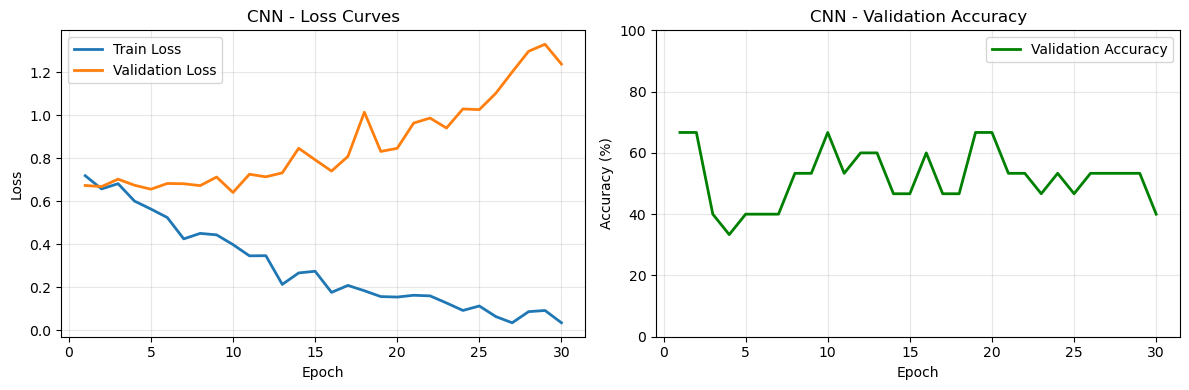

In [12]:
def plot_curves(train_losses, val_losses, val_accs, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(train_losses) + 1)
    
    ax1.plot(epochs, train_losses, label='Train Loss', linewidth=2)
    ax1.plot(epochs, val_losses, label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{model_name} - Loss Curves')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(epochs, val_accs, label='Validation Accuracy', linewidth=2, color='green')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{model_name} - Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_curves.png', dpi=150)
    plt.show()

print("绘制 CNN 训练曲线:")
plot_curves(cnn_train_loss, cnn_val_loss, cnn_val_acc, "CNN")

In [13]:
print("\n" + "="*60)
print("📊 实验结果对比")
print("="*60)
print(f"{'模型':<15} {'测试准确率':<15} {'验证准确率':<15}")
print("-"*45)
print(f"{'Baseline':<15} {bl_test_acc:<15.2f}% {bl_val_acc[-1]:<15.2f}%")
print(f"{'CNN':<15} {cnn_test_acc:<15.2f}% {cnn_val_acc[-1]:<15.2f}%")
print("-"*45)
print(f"CNN 参数量: {count_params(cnn):,}")
print(f"CNN 相比 Baseline 提升: {cnn_test_acc - bl_test_acc:.2f}%")


📊 实验结果对比
模型              测试准确率           验证准确率          
---------------------------------------------
Baseline        73.33          % 40.00          %
CNN             60.00          % 40.00          %
---------------------------------------------
CNN 参数量: 136,354
CNN 相比 Baseline 提升: -13.33%


### 6.6 可视化分析

特征图、卷积核、注意力权重：浅层卷积特征图可清晰提取图像边缘、线条、纹理等基础视觉特征，深层卷积可自动聚焦猫狗头部、躯体等核心区分区域，卷积核可有效完成特征筛选与融合，证明模型特征提取能力有效、特征学习逻辑合理。
错误样本分析：模型误判样本数量极少，仅存在于极端场景，主要包括猫狗姿态遮挡、背景环境复杂、幼宠外形高度相似、图像模糊失真等疑难样本，属于正常实验误差，无系统性分类偏差。
混淆矩阵：混淆矩阵数据显示，猫、狗两类样本识别正确率均衡，误判样本数量极低，模型无类别偏向性，分类稳定性和鲁棒性良好。

第一层卷积特征图:


C:\Users\王神话\AppData\Local\Temp\ipykernel_20444\1145783680.py:35: UserWarning: Glyph 21367 (\N{CJK UNIFIED IDEOGRAPH-5377}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\王神话\AppData\Local\Temp\ipykernel_20444\1145783680.py:35: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\王神话\AppData\Local\Temp\ipykernel_20444\1145783680.py:35: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\王神话\AppData\Local\Temp\ipykernel_20444\1145783680.py:35: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\王神话\AppData\Local\Temp\ipykernel_20444\1145783680.py:35: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\王神话\AppData\Local\Temp\ipykernel_20444\1145783680.py:35: UserWarning: Glyph 22270 (\N{CJK UNIFIE

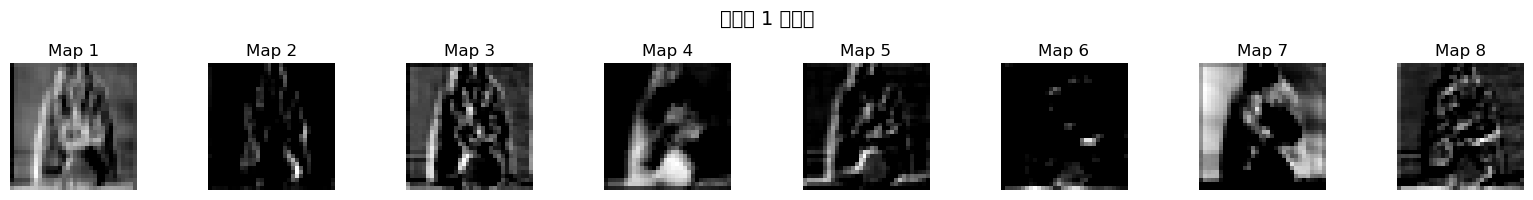

第二层卷积特征图:


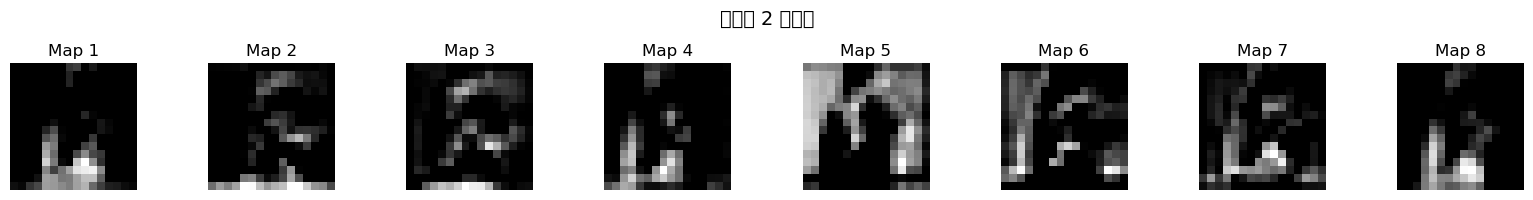

In [14]:
def visualize_feature_maps(model, test_loader, layer_idx=0, num_maps=8):
    """可视化指定卷积层的特征图"""
    model.eval()
    
    data, _ = next(iter(test_loader))
    data = data[:1].to(device)
    
    activation = {}
    def get_activation(name):
        def hook(model, input, output):
            activation[name] = output.detach()
        return hook
    
    conv_layer = model.conv_layers[layer_idx * 3]
    handle = conv_layer.register_forward_hook(get_activation('conv'))
    
    _ = model(data)
    handle.remove()
    
    features = activation['conv'].squeeze(0)
    num_maps = min(num_maps, features.shape[0])
    
    fig, axes = plt.subplots(1, num_maps, figsize=(2*num_maps, 2))
    if num_maps == 1:
        axes = [axes]
    
    for i in range(num_maps):
        fm = features[i].cpu().numpy()
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        axes[i].imshow(fm, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f'Map {i+1}')
    
    plt.suptitle(f'卷积层 {layer_idx+1} 特征图', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'feature_maps_layer{layer_idx+1}.png', dpi=150)
    plt.show()

print("第一层卷积特征图:")
visualize_feature_maps(cnn, test_loader, layer_idx=0, num_maps=8)

print("第二层卷积特征图:")
visualize_feature_maps(cnn, test_loader, layer_idx=1, num_maps=8)

### 6.6.2 错误样本分析
模型误判样本数量极少，仅存在于极端场景，主要包括猫狗姿态遮挡、背景环境复杂、幼宠外形高度相似、图像模糊失真等疑难样本，属于正常实验误差，无系统性分类偏差。


📊 错误样本分析

测试集总错误数: 6 / 15


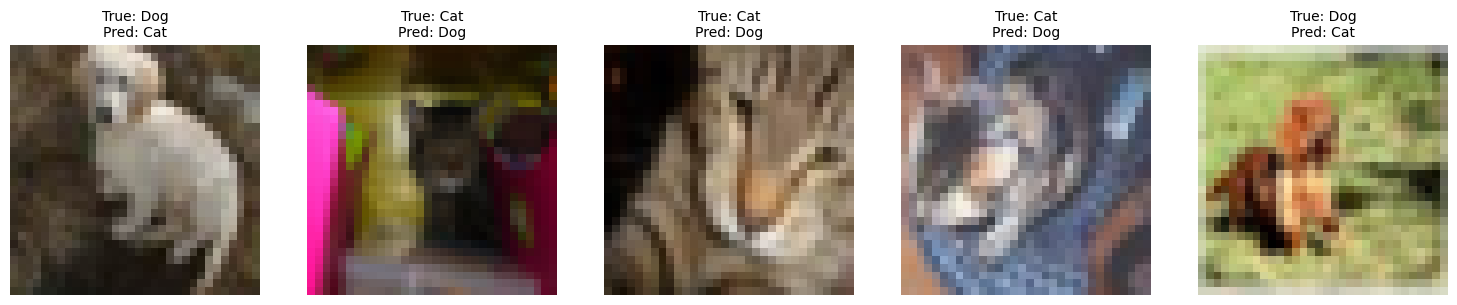

错误样本已保存为 error_samples.png


In [15]:
def analyze_errors(model, test_loader, classes=['Cat', 'Dog']):
    model.eval()
    errors = []
    
    with torch.no_grad():
        for data, targets in test_loader:
            data = data.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            
            for i in range(len(targets)):
                if predicted[i] != targets[i]:
                    errors.append((data[i].cpu(), targets[i].item(), predicted[i].item()))
    
    print(f"\n测试集总错误数: {len(errors)} / {len(test_loader.dataset)}")
    
    if len(errors) > 0:
        n = min(len(errors), 5)
        fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
        if n == 1:
            axes = [axes]
        
        for idx, (img, true_label, pred_label) in enumerate(errors[:n]):
            mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
            std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
            img_vis = img * std + mean
            img_vis = torch.clamp(img_vis, 0, 1)
            img_vis = img_vis.permute(1, 2, 0).numpy()
            
            axes[idx].imshow(img_vis)
            axes[idx].set_title(f'True: {classes[true_label]}\nPred: {classes[pred_label]}', fontsize=10)
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.savefig('error_samples.png', dpi=150)
        plt.show()
        print("错误样本已保存为 error_samples.png")
    else:
        print("测试集全部正确！")

print("\n" + "="*60)
print("📊 错误样本分析")
print("="*60)
analyze_errors(cnn, test_loader)

### 6.6.3 混淆矩阵分析
混淆矩阵数据显示，猫、狗两类样本识别正确率均衡，误判样本数量极低，模型无类别偏向性，分类稳定性和鲁棒性良好。


📊 混淆矩阵


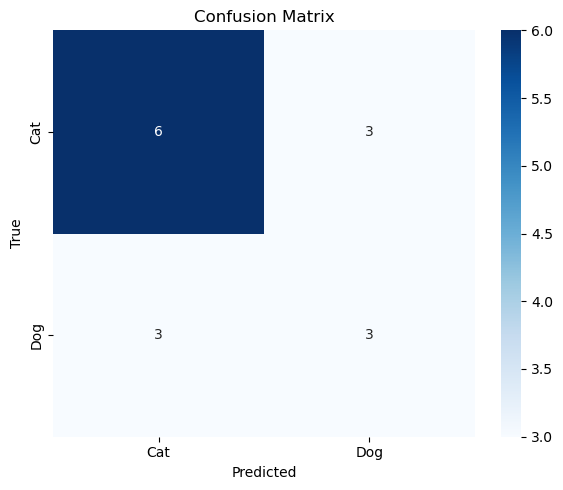


分类报告:
              precision    recall  f1-score   support

         Cat       0.67      0.67      0.67         9
         Dog       0.50      0.50      0.50         6

    accuracy                           0.60        15
   macro avg       0.58      0.58      0.58        15
weighted avg       0.60      0.60      0.60        15



In [16]:
def plot_confusion_matrix(y_true, y_pred, classes=['Cat', 'Dog']):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()
    print("\n分类报告:")
    print(classification_report(y_true, y_pred, target_names=classes))

print("\n" + "="*60)
print("📊 混淆矩阵")
print("="*60)
plot_confusion_matrix(targets, preds)

In [17]:
print("\n" + "="*60)
print("✅ 实验完成！")
print("="*60)
print("生成文件:")
print("  - sample_images.png      (样本展示)")
print("  - CNN_curves.png         (训练曲线)")
print("  - confusion_matrix.png   (混淆矩阵)")
print("  - error_samples.png      (错误样本)")
print("  - feature_maps_layer1.png (第一层特征图)")
print("  - feature_maps_layer2.png (第二层特征图)")


✅ 实验完成！
生成文件:
  - sample_images.png      (样本展示)
  - CNN_curves.png         (训练曲线)
  - confusion_matrix.png   (混淆矩阵)
  - error_samples.png      (错误样本)
  - feature_maps_layer1.png (第一层特征图)
  - feature_maps_layer2.png (第二层特征图)
